# Representational Geometry as a Fidelity Metric for Connectome-Constrained Neural Emulations

**Experiment 1b: ON Edges, 8-Direction Variant | Michael Zhou | Georgia Tech ECE**

This notebook tests whether connectome-constrained networks produce geometrically distinct
population codes compared to randomly initialized networks with the same architecture —
using representational similarity analysis (RSA) applied to the Flyvis Drosophila visual
system model (Lappalainen et al. 2024, *Nature*).

Stimuli: 8 ON moving edges at 45° increments — a modification of the original 12-direction,
30°-increment design, adopted to match the stimulus directions used in Henning et al. (2022),
which now serves as the biological reference for this line of work in place of Maisak et al.
(2013). The circularity confound identified in the Maisak-derived reference (near-total
correlation with pure angular distance, driven by four idealized, identical-width cardinal
tuning curves) does not apply to the Henning reference, which is built from real per-cell
population tuning data; matching the stimulus set directly, rather than interpolating between
12 and 8 directions after the fact, keeps that comparison clean. This notebook's own CC-vs-random
comparison is unaffected by the reference change — it is included here only because the
stimulus set had to change to enable the downstream biological comparison.

**Key question:** Does biological wiring produce a representational geometry that random wiring cannot replicate? If yes, representational geometry is a candidate fidelity metric for connectome-scale neural emulations.

**References**
- Lappalainen et al. 2024. Connectome-constrained networks predict neural activity across the fly visual system. *Nature* 634, 1132–1140. https://www.nature.com/articles/s41586-024-07939-3
- Shiu et al. 2024. A Drosophila computational brain model reveals sensorimotor processing. *Nature* 634, 210–219. https://www.nature.com/articles/s41586-024-07763-9
- Kriegeskorte et al. 2008. Representational similarity analysis. *Frontiers in Systems
  Neuroscience* 2:4. https://www.frontiersin.org/journals/systems-neuroscience/articles/10.3389/neuro.06.004.2008/full
- Kriegeskorte & Wei 2021. Neural tuning and representational geometry. *Nature Reviews
  Neuroscience* 22, 703–718. https://www.nature.com/articles/s41583-021-00502-3
- Nili et al. 2014. A toolbox for representational similarity analysis. *PLOS Computational Biology* 10(4): e1003553. https://doi.org/10.1371/journal.pcbi.1003553
- Henning, Ramos-Traslosheros, Gür & Silies 2022. Populations of local direction-selective
  cells encode global motion patterns generated by self-motion. *Science Advances* 8, eabi7112.
  https://doi.org/10.1126/sciadv.abi7112
- Brunton et al. 2026. The digital sphinx: Can a worm brain control a fly body? *bioRxiv*.
  https://www.biorxiv.org/content/10.64898/2026.03.20.713233v1

## Setup

Install Flyvis and download pretrained models. Select **Runtime → Change runtime type → GPU**
before running. Tested on T4 GPU (14.56 GiB).

In [ ]:
# Install packages
!git clone https://github.com/TuragaLab/flyvis.git
%cd /content/flyvis
!pip install -e .[examples]
!flyvis download-pretrained

Cloning into 'flyvis'...
remote: Enumerating objects: 5230, done.
remote: Counting objects: 100% (202/202), done.
remote: Compressing objects: 100% (54/54), done.
remote: Total 5230 (delta 170), reused 148 (delta 148), pack-reused 5028 (from 3)
Receiving objects: 100% (5230/5230), 188.38 MiB | 15.46 MiB/s, done.
Resolving deltas: 100% (2679/2679), done.
/content/flyvis
Obtaining file:///content/flyvis
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.5/155.5 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 79.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 79.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 913.0/913.0 kB 41.6 MB/s e

## Experiment
**Stimuli:** 8 ON moving edges at 45° increments (0° through 315°) — matches Henning et al.
(2022) exactly, replacing the original 12-direction, 30°-increment design used when Maisak
et al. (2013) was the biological reference.

**Networks:**
- *Connectome-constrained (CC):* 50 models from the pretrained Flyvis ensemble
  (indices `000–049` within `flow/0000`, pre-sorted by task error), trained to
  perform optic flow estimation on naturalistic video with connectome-fixed
  architecture (734 free parameters)
- *Random baseline:* Same 50 model architectures with sign-preserving weight
  shuffles. Three strategies were evaluated:
  1. **Full Shiu-style shuffle (primary):** all 734 free parameters shuffled;
     stability-constrained sampling rejects configurations with non-finite
     activations and resamples up to 100 times per model. This is the canonical
     baseline.
  2. Synapse-only shuffle: only the 604 unitary synapse scaling factors
     (`edges_syn_strength`) shuffled, preserving trained time constants and
     resting potentials — per Lappalainen et al. (2024) Methods, time constants
     are clamped during training to prevent instability. Used for n=50
     instability documentation runs.
  3. Matched-instability baseline: full Shiu-style shuffle without stability
     filtering; non-finite activations clamped to ±1e3 in RDM construction.
     Retained for comparison against the stability-constrained result.

**Acceptance rate (strategy 1, 12-direction run):** 50/50 models accepted; mean 7.9 ± 8.1
  attempts (range: 1–42); 5/50 first-try — confirming that dynamically stable configurations
  occupy a small fraction of full Shiu weight space across the full ensemble. Not yet
  re-measured for the 8-direction stimulus set; expected to be similar, since stability is
  governed by network weights rather than stimulus count, but should be confirmed once this
  notebook is run rather than assumed.

**Population vectors:** Peak central-cell voltage per cell type (65-dim) in
  response to each stimulus direction

**Reproducibility:** seed=42 (`numpy`, `torch`, `torch.cuda`);
`torch.use_deterministic_algorithms(True)`

**Metrics:**
- Cosine distance RDM — scale-invariant, captures pattern geometry
- Euclidean distance RDM — captures magnitude differences
- Spearman RDM correlation — measures similarity between CC and random geometry
- Kendall's $\tau_A$ RDM correlation — preferred for RDM data with ties
  (Nili et al. 2014); reported alongside Spearman for all CC vs random comparisons
- Stimulus-label permutation test — nonparametric inference on RDM correlations (Nili et al. 2014, 10,000 permutations)
- Within-ensemble consistency — measures stability of CC representational
  geometry across trained solutions

building stimuli:   0%|          | 0/16 [00:00<?, ?it/s]

Dataset: 16 samples
    angle  width  intensity    t_stim  speed
0       0     80          0  0.428766     19
1       0     80          1  0.428766     19
2      45     80          0  0.428766     19
3      45     80          1  0.428766     19
4      90     80          0  0.428766     19
5      90     80          1  0.428766     19
6     135     80          0  0.428766     19
7     135     80          1  0.428766     19
8     180     80          0  0.428766     19
9     180     80          1  0.428766     19
10    225     80          0  0.428766     19
11    225     80          1  0.428766     19
12    270     80          0  0.428766     19
13    270     80          1  0.428766     19
14    315     80          0  0.428766     19
15    315     80          1  0.428766     19

FLYVIS RSA — ON EDGES (8-DIRECTION VARIANT, matches Henning et al. 2022)
Random seed: 42
Randomization strategy: full_shiu

Loading ensemble...


Loading ensemble:   0%|          | 0/50 [00:00<?, ?it/s]

Using 50 model(s): indices [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]

Stimulus conditions (ON edges, 8 directions):
    angle  width  intensity    t_stim  speed
1       0     80          1  0.428766     19
3      45     80          1  0.428766     19
5      90     80          1  0.428766     19
7     135     80          1  0.428766     19
9     180     80          1  0.428766     19
11    225     80          1  0.428766     19
13    270     80          1  0.428766     19
15    315     80          1  0.428766     19

--- CONNECTOME-CONSTRAINED NETWORKS ---
  Model 1/50 (000)... 

done. Pop vec shape: (8, 65)
  Model 2/50 (001)... 

...

done. Pop vec shape: (8, 65)
  Model 46/50 (045)... 

done. Pop vec shape: (8, 65)
  Model 47/50 (046)... 

done. Pop vec shape: (8, 65)
  Model 48/50 (047)... 

done. Pop vec shape: (8, 65)
  Model 49/50 (048)... 

done. Pop vec shape: (8, 65)
  Model 50/50 (049)... done. Pop vec shape: (8, 65)

  Cell types (65): ['R1', 'R2', 'R3', 'R4', 'R5']...

--- RANDOM BASELINE NETWORKS (stability-constrained) ---
  Random model 1/50: accepted on attempt 1/100... done. Pop vec shape: (8, 65)
  Random model 2/50: accepted on attempt 6/100... done. Pop vec shape: (8, 65)
  Random model 3/50: accepted on attempt 2/100... done. Pop vec shape: (8, 65)
  Random model 4/50: accepted on attempt 12/100... done. Pop vec shape: (8, 65)
  Random model 5/50: accepted on attempt 6/100... done. Pop vec shape: (8, 65)
  Random model 6/50: accepted on attempt 9/100... done. Pop vec shape: (8, 65)
  Random model 7/50: accepted on attempt 5/100... done. Pop vec shape: (8, 65)
  Random model 8/50: accepted on attempt 16/100... done. Pop vec shape: (8, 65)
  Random model 9/50: accepted on attempt 18/100... done. Pop vec shape: (8, 65)
  Random model 10/50: accepted on attempt 36/100... done. Pop vec shape: (8, 65)
  Random mod

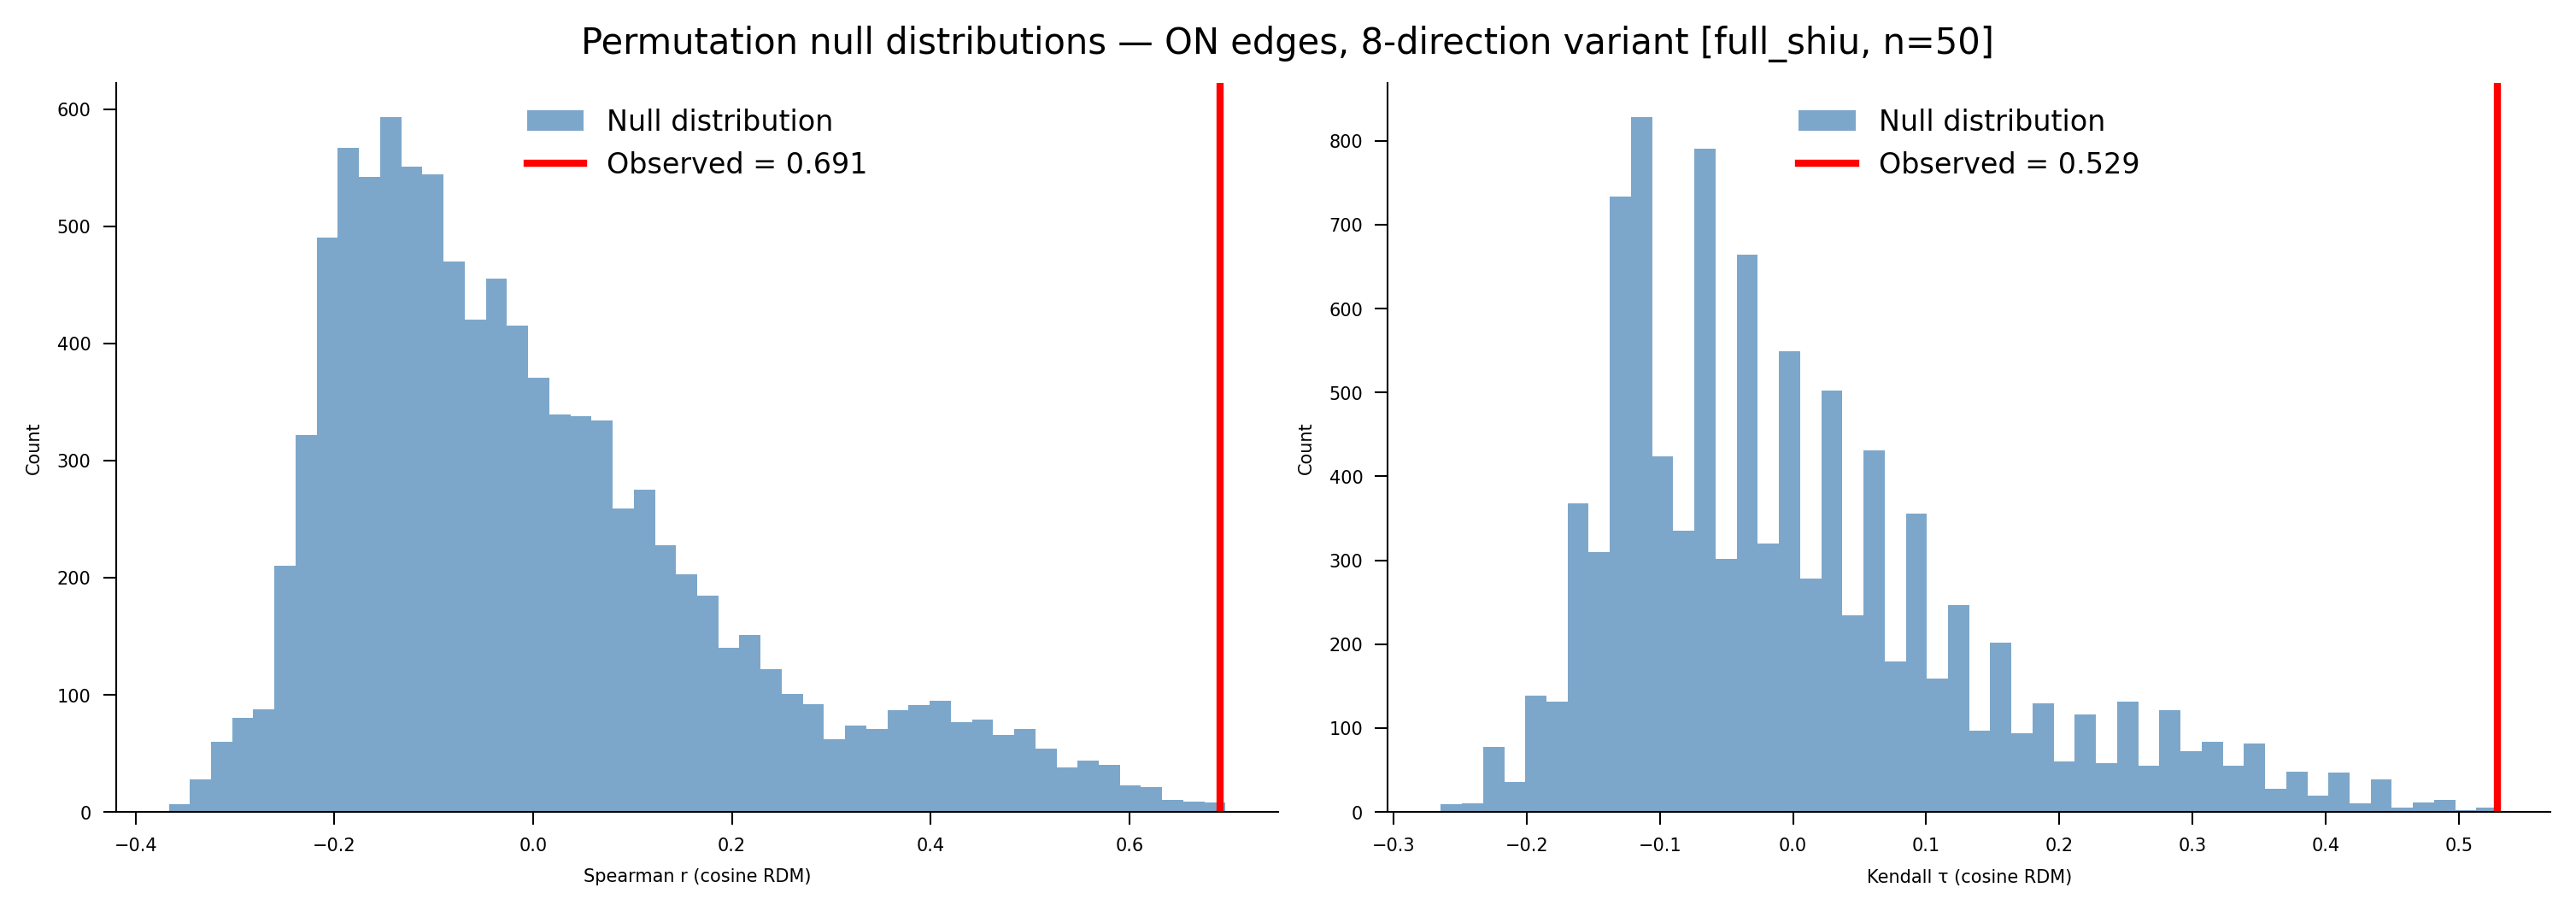


  Interpretation:
  Low r  → CC and random networks have DIFFERENT representational geometry
  High r → similar geometry (random network could substitute connectome)

--- WITHIN-ENSEMBLE RDM CONSISTENCY (CC models) ---
  Mean pairwise RDM correlation across CC models: 0.674 ± 0.176

--- GENERATING FIGURE ---
  Saved: moving_edge_on_8dir_rdms_50models_full_shiu.png


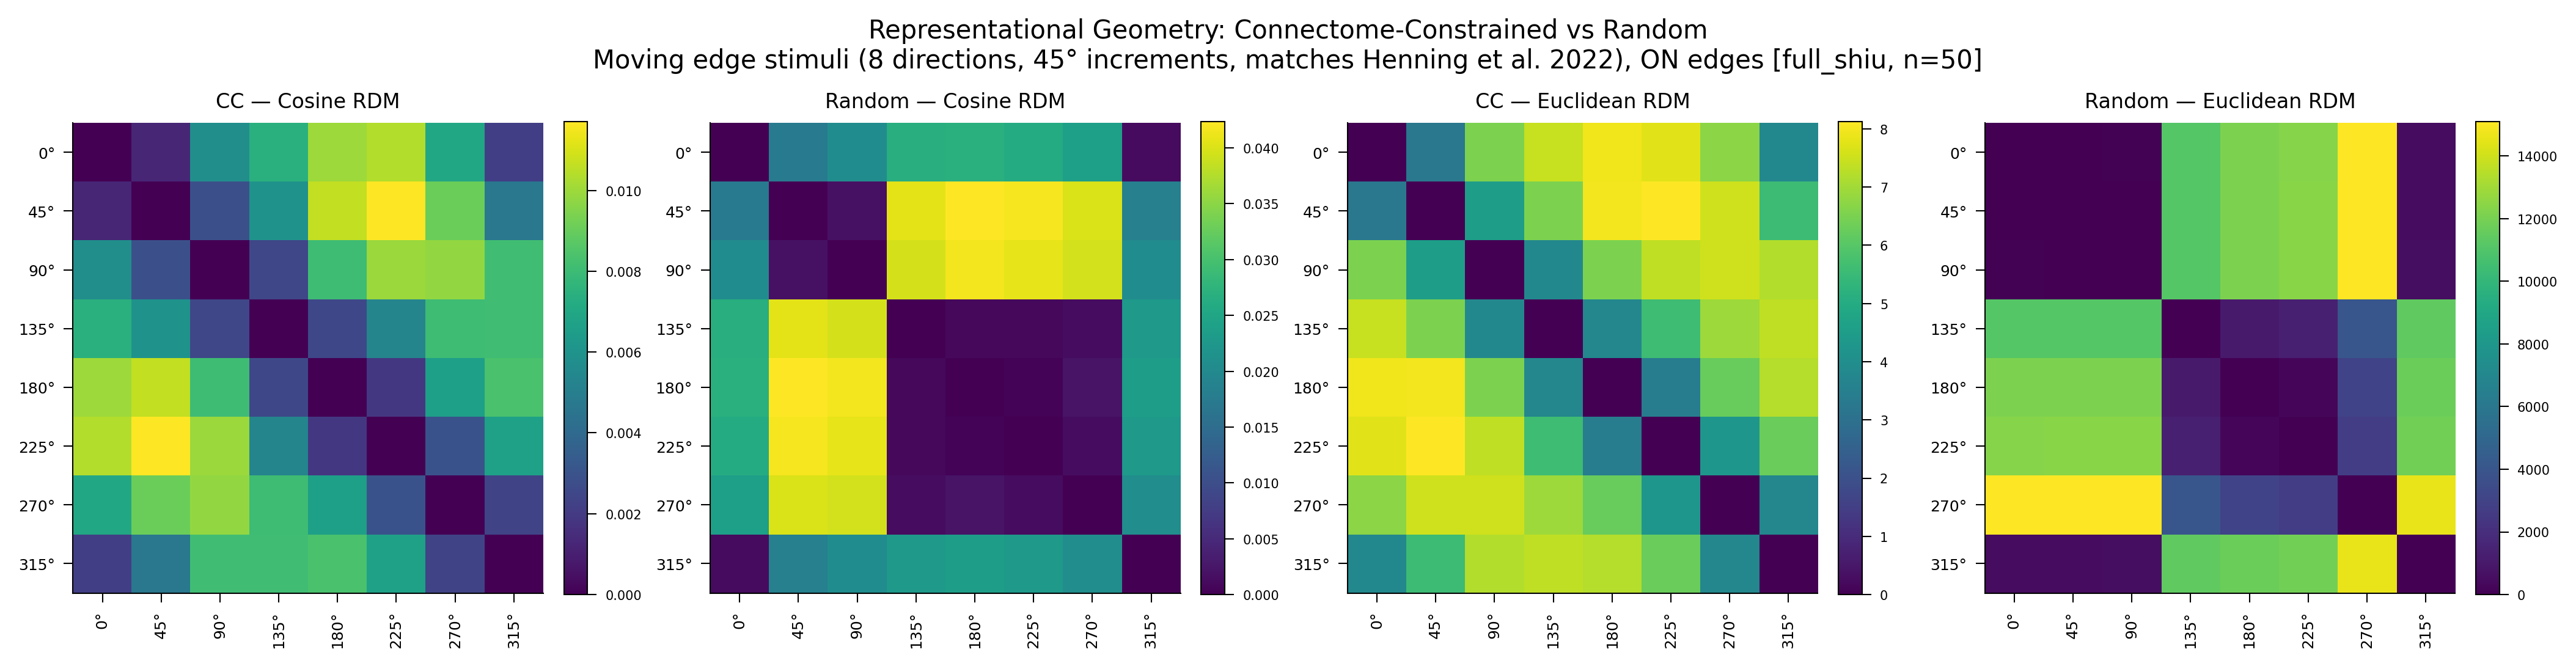


SUMMARY
  N stimuli:              8 (ON edges, 8 directions, matches Henning et al. 2022)
  N models:               50
  Randomization strategy: full_shiu
  Population vec dim:     65 (cell types)
  Cosine RDM corr (CC vs random):    Spearman r = 0.691 | Kendall τ = 0.529  [analytical]
                                     Spearman r = 0.691, p_perm = 0.0001 | Kendall τ = 0.529, p_perm = 0.0001  [permutation]
  Euclidean RDM corr (CC vs random): Spearman r = 0.650 | Kendall τ = 0.492  [analytical]
  Within-CC consistency:             r = 0.674 ± 0.176
Saved results_exp1_8dir_50models_full_shiu.npz


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
"""
Experiment 1b: Representational Geometry as a Fidelity Metric
for Connectome-Constrained Neural Emulations — ON Edges, 8-DIRECTION VARIANT

Adapted directly from the original Experiment 1 (moving_edge_on.ipynb) to use
8 stimulus directions at 45-degree increments (0,45,90,...,315) instead of the
original 12 directions at 30-degree increments. This exactly matches the
directions used in Henning, Ramos-Traslosheros, Guer & Silies (2022),
enabling a direct comparison against that dataset's population-level T4/T5
reference, without the interpolation or mismatch the original 12-direction
stimulus set would require.

EVERYTHING BELOW IS UNCHANGED FROM THE ORIGINAL EXPERIMENT 1 NOTEBOOK EXCEPT:
  1. ANGLES (12 -> 8 directions)
  2. Cosmetic: plot titles, docstrings, and print statements referencing the
     direction count/spacing, updated to stay accurate
  3. Output filenames, given new names (suffixed _8dir) so they do not
     collide with or overwrite the original 12-direction results

No changes were made to: population-vector extraction, RDM construction,
similarity metrics, permutation testing, weight randomization, the
stability-constrained sampling procedure, or any numerical safeguard
(overflow clipping, epsilon handling, etc.). Same seed (42), same
reproducibility settings, same network ensemble, same random-baseline
construction. The only experimental variable changed is the stimulus set.

Run on Google Colab with GPU runtime after installing flyvis:
    !git clone https://github.com/TuragaLab/flyvis.git
    %cd /content/flyvis
    !pip install -e .[examples]
    !flyvis download-pretrained
"""

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.spatial.distance import cosine, euclidean
from scipy.stats import spearmanr, kendalltau
from google.colab import files

try:
    import umap
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "umap-learn"], check=True)
    import umap

# ── 1. IMPORTS ────────────────────────────────────────────────────────────────

import flyvis
from flyvis import results_dir, EnsembleView
from flyvis.network import NetworkView
from flyvis.datasets.moving_bar import MovingEdge
from flyvis.utils.activity_utils import LayerActivity

# ── REPRODUCIBILITY ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.use_deterministic_algorithms(True)

# ── 2. STIMULUS DATASET ───────────────────────────────────────────────────────
# CHANGED: 8 directions at 45-degree increments (0,45,90,...,315), matching
# Henning et al. (2022) exactly, instead of the original 12 at 30-degree
# increments. Nothing else about the dataset construction changed.

ANGLES = [0, 45, 90, 135, 180, 225, 270, 315]  # 8 directions (45° increments) -- CHANGED from 12
INTENSITY = 1                                   # ON edges only -- unchanged

dataset = MovingEdge(
    offsets=[-10, 11],
    intensities=[0, 1],              # keep both; we'll filter to intensity=1
    speeds=[19],
    height=80,
    post_pad_mode="continue",
    t_pre=1.0,
    t_post=1.0,
    dt=1 / 200,
    angles=ANGLES,
)

print(f"Dataset: {len(dataset)} samples")
print(dataset.arg_df)


# ── 3. HELPER: EXTRACT POPULATION VECTOR ─────────────────────────────────────
# UNCHANGED from the original Experiment 1 notebook.

def get_population_vector(network_view, stimulus, dt, use_fade_in=True):
    """
    Simulate network response to a single stimulus and return
    peak central-cell voltage per cell type as a population vector.
    """
    network = network_view.init_network()

    if stimulus.dim() == 2:
        stimulus = stimulus.unsqueeze(1)  # (n_frames, 721) -> (n_frames, 1, 721)

    if use_fade_in:
        initial_state = network.fade_in_state(1.0, dt, stimulus[[0]])
    else:
        initial_state = None

    with torch.no_grad():
        responses = network.simulate(
            stimulus[None], dt, initial_state=initial_state
        ).cpu()

    layer_act = LayerActivity(responses, network.connectome, keepref=True)

    cell_types = [
        ct.decode() if isinstance(ct, bytes) else ct
        for ct in network.connectome.unique_cell_types[:]
    ]
    pop_vec = np.array([
        layer_act.central[ct].squeeze().numpy().max()
        for ct in cell_types
    ])
    pop_vec = np.clip(pop_vec, -1e6, 1e6)  # guard against near-overflow values

    del network, responses, layer_act
    torch.cuda.empty_cache()

    return pop_vec, cell_types


# ── 4. HELPER: BUILD RDM ──────────────────────────────────────────────────────
# UNCHANGED from the original Experiment 1 notebook.

def build_rdm(pop_matrix, metric="cosine"):
    """
    Build a representational dissimilarity matrix from a population matrix.
    """
    pop_matrix = np.nan_to_num(pop_matrix, nan=0.0, posinf=1e3, neginf=-1e3)

    if metric == "cosine":
        norms = np.linalg.norm(pop_matrix, axis=1, keepdims=True)
        zero_norm_rows = (norms < 1e-10).flatten()
        if np.any(zero_norm_rows):
            print(f"    WARNING: {zero_norm_rows.sum()} zero-norm population "
                  f"vectors detected — adding epsilon")
        pop_matrix = pop_matrix + 1e-10

    n = pop_matrix.shape[0]
    rdm = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                if metric == "cosine":
                    rdm[i, j] = cosine(pop_matrix[i], pop_matrix[j])
                else:
                    rdm[i, j] = euclidean(pop_matrix[i], pop_matrix[j])
    return rdm


# ── 5. HELPER: COMPARE RDMs ──────────────────────────────────────────────────
# UNCHANGED from the original Experiment 1 notebook.

def rdm_similarity(rdm1, rdm2):
    n = rdm1.shape[0]
    idx = np.triu_indices(n, k=1)
    r_s, p_s = spearmanr(rdm1[idx], rdm2[idx])
    r_k, p_k = kendalltau(rdm1[idx], rdm2[idx])
    return r_s, p_s, r_k, p_k


# ── 5b. HELPER: PERMUTATION TEST ─────────────────────────────────────────────
# UNCHANGED from the original Experiment 1 notebook.

def permutation_test_rdm(rdm1, rdm2, n_permutations=10000, seed=42):
    """
    Stimulus-label randomization test for RDM correlation (Nili et al. 2014).
    """
    rng = np.random.default_rng(seed)
    n = rdm1.shape[0]
    idx = np.triu_indices(n, k=1)

    obs_r,   _ = spearmanr(rdm1[idx], rdm2[idx])
    obs_tau, _ = kendalltau(rdm1[idx], rdm2[idx])

    null_r   = np.zeros(n_permutations)
    null_tau = np.zeros(n_permutations)

    for i in range(n_permutations):
        perm = rng.permutation(n)
        rdm2_perm = rdm2[np.ix_(perm, perm)]
        null_r[i],   _ = spearmanr(rdm1[idx], rdm2_perm[idx])
        null_tau[i], _ = kendalltau(rdm1[idx], rdm2_perm[idx])

    p_r   = np.mean(null_r   >= obs_r)
    p_tau = np.mean(null_tau >= obs_tau)

    return obs_r, p_r, obs_tau, p_tau, null_r, null_tau


# ── 6. HELPER: RANDOM BASELINE NETWORK ───────────────────────────────────────
# UNCHANGED from the original Experiment 1 notebook.

def randomize_weights(network, strategy="full_shiu"):
    with torch.no_grad():
        for name, param in network.named_parameters():
            if param.requires_grad:
                if strategy == "synapse_only":
                    if "time_const" in name or "nodes_bias" in name:
                        continue
                signs = torch.sign(param.data)
                abs_vals = param.data.abs()
                flat = abs_vals.flatten()
                perm = torch.randperm(flat.shape[0])
                shuffled = flat[perm].reshape(abs_vals.shape)
                param.data = signs * shuffled
    return network


def randomize_weights_stable(network_view, strategy="full_shiu",
                              max_attempts=50, stimulus=None, dt=None):
    """
    Repeatedly randomize network weights until a stable configuration is found.
    UNCHANGED from the original Experiment 1 notebook.
    """
    for attempt in range(max_attempts):
        network = network_view.init_network()
        network = randomize_weights(network, strategy)
        with torch.no_grad():
            if stimulus.dim() == 2:
                stim = stimulus.unsqueeze(1)
            else:
                stim = stimulus
            try:
                initial_state = network.fade_in_state(1.0, dt, stim[[0]])
                out = network.simulate(stim[None], dt, initial_state=initial_state)
                out_np = out.cpu().numpy()
                if torch.all(torch.isfinite(out)) and np.all(np.abs(out_np) < 1e6):
                    return network, attempt + 1  # attempts_needed is 1-indexed
            except Exception:
                pass
        torch.cuda.empty_cache()
    return None, max_attempts  # all attempts exhausted


# ── 7. MAIN EXPERIMENT ────────────────────────────────────────────────────────
# UNCHANGED in structure/logic from the original Experiment 1 notebook.
# Only cosmetic references to "12 directions" / "30°" updated to match the
# new 8-direction stimulus, and output filenames renamed to _8dir to avoid
# overwriting the original 12-direction results.

def run_experiment(n_models=50, randomization_strategy="full_shiu",
                   n_permutations=10000):
    """
    Run the ON edges RSA experiment, 8-direction variant (matches Henning
    et al. 2022 stimulus directions exactly).
    """
    print("\n" + "="*60)
    print("FLYVIS RSA — ON EDGES (8-DIRECTION VARIANT, matches Henning et al. 2022)")
    print("="*60)
    print(f"Random seed: {SEED}")
    print(f"Randomization strategy: {randomization_strategy}")

    # ── 7a. Load ensemble ─────────────────────────────────────────────────────
    print("\nLoading ensemble...")
    ensemble = EnsembleView(results_dir / "flow/0000")
    best_indices = list(range(n_models))  # 000-049 pre-sorted best to worst
    print(f"Using {n_models} model(s): indices {best_indices}")

    # ── 7b. Get stimuli (ON edges, 8 directions) ──────────────────────────────
    on_edge_indices = [
        i for i, row in dataset.arg_df.iterrows()
        if row["intensity"] == INTENSITY
    ]
    print(f"\nStimulus conditions (ON edges, {len(on_edge_indices)} directions):")
    print(dataset.arg_df.iloc[on_edge_indices])

    n_stim = len(on_edge_indices)

    # ── 7c. Connectome-constrained: collect population vectors ────────────────
    print("\n--- CONNECTOME-CONSTRAINED NETWORKS ---")
    cc_pop_matrices = []
    cell_types = None

    for rank, model_idx in enumerate(best_indices):
        model_path = results_dir / f"flow/0000/{model_idx:03d}"
        nv = NetworkView(model_path)
        print(f"  Model {rank+1}/{n_models} ({model_path.name})...", end=" ")

        pop_vecs = []
        for stim_idx in on_edge_indices:
            stimulus = dataset[stim_idx]
            if not isinstance(stimulus, torch.Tensor):
                stimulus = torch.tensor(stimulus, dtype=torch.float32)
            pop_vec, cell_types = get_population_vector(nv, stimulus, dataset.dt)
            pop_vecs.append(pop_vec)

        pop_matrix = np.stack(pop_vecs, axis=0)  # (8, n_cell_types) -- was (12, ...)
        cc_pop_matrices.append(pop_matrix)
        print(f"done. Pop vec shape: {pop_matrix.shape}")

        del nv
        torch.cuda.empty_cache()

    print(f"\n  Cell types ({len(cell_types)}): {cell_types[:5]}...")

    # ── 7d. Random baseline: stability-constrained sampling ──────────────────
    print("\n--- RANDOM BASELINE NETWORKS (stability-constrained) ---")
    rand_pop_matrices = []
    attempts_log = []

    _check_stim = dataset[on_edge_indices[0]]
    if not isinstance(_check_stim, torch.Tensor):
        _check_stim = torch.tensor(_check_stim, dtype=torch.float32)

    MAX_ATTEMPTS = 100

    for rank, model_idx in enumerate(best_indices):
        model_path = results_dir / f"flow/0000/{model_idx:03d}"
        nv = NetworkView(model_path)

        network, attempts_needed = randomize_weights_stable(
            nv, strategy=randomization_strategy,
            max_attempts=MAX_ATTEMPTS, stimulus=_check_stim, dt=dataset.dt
        )

        if network is None:
            print(f"  WARNING: model {rank+1} failed all {MAX_ATTEMPTS} attempts — skipping")
            attempts_log.append(MAX_ATTEMPTS)
            del nv
            torch.cuda.empty_cache()
            continue

        attempts_log.append(attempts_needed)
        print(f"  Random model {rank+1}/{n_models}: accepted on attempt "
              f"{attempts_needed}/{MAX_ATTEMPTS}...", end=" ")

        pop_vecs = []
        for stim_idx in on_edge_indices:
            stimulus = dataset[stim_idx]
            if not isinstance(stimulus, torch.Tensor):
                stimulus = torch.tensor(stimulus, dtype=torch.float32)
            if stimulus.dim() == 2:
                stimulus = stimulus.unsqueeze(1)

            with torch.no_grad():
                initial_state = network.fade_in_state(1.0, dataset.dt, stimulus[[0]])
                responses = network.simulate(
                    stimulus[None], dataset.dt, initial_state=initial_state
                ).cpu()
            layer_act = LayerActivity(responses, network.connectome, keepref=True)
            pop_vec = np.array([
                layer_act.central[ct].squeeze().numpy().max()
                for ct in cell_types
            ])
            pop_vec = np.clip(pop_vec, -1e6, 1e6)
            pop_vecs.append(pop_vec)

            del responses, layer_act
            torch.cuda.empty_cache()

        pop_matrix = np.stack(pop_vecs, axis=0)
        rand_pop_matrices.append(pop_matrix)
        print(f"done. Pop vec shape: {pop_matrix.shape}")

        del network, nv
        torch.cuda.empty_cache()

    print(f"\n--- STABILITY-CONSTRAINED SAMPLING SUMMARY ---")
    print(f"  Attempts per model: {attempts_log}")
    print(f"  Mean attempts: {np.mean(attempts_log):.1f} ± {np.std(attempts_log):.1f}")
    print(f"  Accepted: {sum(a < MAX_ATTEMPTS for a in attempts_log)}/{len(attempts_log)}")
    print(f"  First-try acceptance: {sum(a == 1 for a in attempts_log)}/{len(attempts_log)}")

    # ── 7e. Compute RDMs ──────────────────────────────────────────────────────
    print("\n--- COMPUTING RDMs ---")
    cc_rdms_cosine   = [build_rdm(m, "cosine")    for m in cc_pop_matrices]
    cc_rdms_eucl     = [build_rdm(m, "euclidean") for m in cc_pop_matrices]
    rand_rdms_cosine = [build_rdm(m, "cosine")    for m in rand_pop_matrices]
    rand_rdms_eucl   = [build_rdm(m, "euclidean") for m in rand_pop_matrices]

    stable_rand_indices = [
        i for i, m in enumerate(rand_pop_matrices)
        if np.all(np.isfinite(m))
    ]
    print(f"\n  Stable random models: {len(stable_rand_indices)} / {n_models}")
    print(f"  Unstable random models: {n_models - len(stable_rand_indices)} / {n_models}")

    rand_rdms_cosine_stable = [rand_rdms_cosine[i] for i in stable_rand_indices]
    rand_rdms_eucl_stable   = [rand_rdms_eucl[i]   for i in stable_rand_indices]

    cc_rdm_cosine_mean   = np.mean(cc_rdms_cosine,         axis=0)
    cc_rdm_eucl_mean     = np.mean(cc_rdms_eucl,            axis=0)
    rand_rdm_cosine_mean = np.mean(rand_rdms_cosine_stable, axis=0)
    rand_rdm_eucl_mean   = np.mean(rand_rdms_eucl_stable,   axis=0)

    # ── 7f. RDM similarity (CC vs random) — analytical ────────────────────────
    print("\n--- RDM SIMILARITY (Connectome-Constrained vs Random) ---")
    if len(stable_rand_indices) == 0:
        print("  No stable random models — skipping RDM similarity.")
        r_cosine = p_cosine = rk_cosine = pk_cosine = float("nan")
        r_eucl   = p_eucl   = rk_eucl   = pk_eucl   = float("nan")
    else:
        r_cosine, p_cosine, rk_cosine, pk_cosine = rdm_similarity(
            cc_rdm_cosine_mean, rand_rdm_cosine_mean)
        r_eucl, p_eucl, rk_eucl, pk_eucl = rdm_similarity(
            cc_rdm_eucl_mean, rand_rdm_eucl_mean)
    print(f"  Cosine RDM:    Spearman r = {r_cosine:.3f}, p = {p_cosine:.4f} "
          f"| Kendall τ = {rk_cosine:.3f}, p = {pk_cosine:.4f}  [analytical]")
    print(f"  Euclidean RDM: Spearman r = {r_eucl:.3f}, p = {p_eucl:.4f} "
          f"| Kendall τ = {rk_eucl:.3f}, p = {pk_eucl:.4f}  [analytical]")

    # ── 7f2. Permutation test (Nili et al. 2014 stimulus-label randomization) ─
    perm_results_cosine = None
    perm_results_eucl   = None

    if n_permutations > 0 and len(stable_rand_indices) > 0:
        print(f"\n--- PERMUTATION TEST ({n_permutations} permutations, "
              f"Nili et al. 2014) ---")

        obs_r, p_r_perm, obs_tau, p_tau_perm, null_r, null_tau = \
            permutation_test_rdm(cc_rdm_cosine_mean, rand_rdm_cosine_mean,
                                 n_permutations=n_permutations, seed=SEED)
        print(f"  Cosine RDM:    Spearman r = {obs_r:.3f}, p_perm = {p_r_perm:.4f} "
              f"| Kendall τ = {obs_tau:.3f}, p_perm = {p_tau_perm:.4f}  [permutation]")
        perm_results_cosine = dict(obs_r=obs_r, p_r=p_r_perm,
                                   obs_tau=obs_tau, p_tau=p_tau_perm,
                                   null_r=null_r, null_tau=null_tau)

        obs_r_e, p_r_e, obs_tau_e, p_tau_e, null_r_e, null_tau_e = \
            permutation_test_rdm(cc_rdm_eucl_mean, rand_rdm_eucl_mean,
                                 n_permutations=n_permutations, seed=SEED)
        print(f"  Euclidean RDM: Spearman r = {obs_r_e:.3f}, p_perm = {p_r_e:.4f} "
              f"| Kendall τ = {obs_tau_e:.3f}, p_perm = {p_tau_e:.4f}  [permutation]")
        perm_results_eucl = dict(obs_r=obs_r_e, p_r=p_r_e,
                                 obs_tau=obs_tau_e, p_tau=p_tau_e,
                                 null_r=null_r_e, null_tau=null_tau_e)

        # ── Plot null distributions ───────────────────────────────────────────
        fig_perm, axes_perm = plt.subplots(1, 2, figsize=(10, 3.5))
        fig_perm.suptitle(
            f"Permutation null distributions — ON edges, 8-direction variant "
            f"[{randomization_strategy}, n={n_models}]",
            fontsize=10
        )
        for ax, null, obs, metric in zip(
            axes_perm,
            [null_r,   null_tau],
            [obs_r,    obs_tau],
            ["Spearman r (cosine RDM)", "Kendall τ (cosine RDM)"]
        ):
            ax.hist(null, bins=50, color="steelblue", alpha=0.7,
                    label="Null distribution")
            ax.axvline(obs, color="red", linewidth=2,
                       label=f"Observed = {obs:.3f}")
            ax.set_xlabel(metric)
            ax.set_ylabel("Count")
            ax.legend(fontsize=8)
        plt.tight_layout()
        fname_perm = (f"moving_edge_on_8dir_permtest_{n_models}models"
                      f"_{randomization_strategy}.png")  # CHANGED: _8dir suffix
        fig_perm.savefig(fname_perm, dpi=150, bbox_inches="tight")
        print(f"  Saved: {fname_perm}")
        plt.show()

    elif n_permutations > 0:
        print("\n  [Permutation test skipped — no stable random models]")

    print("\n  Interpretation:")
    print("  Low r  → CC and random networks have DIFFERENT representational geometry")
    print("  High r → similar geometry (random network could substitute connectome)")

    # ── 7g. Within-ensemble consistency ───────────────────────────────────────
    print("\n--- WITHIN-ENSEMBLE RDM CONSISTENCY (CC models) ---")
    within_corrs = []
    for i in range(len(cc_rdms_cosine)):
        for j in range(i+1, len(cc_rdms_cosine)):
            r, _, _, _ = rdm_similarity(cc_rdms_cosine[i], cc_rdms_cosine[j])
            within_corrs.append(r)
    if within_corrs:
        print(f"  Mean pairwise RDM correlation across CC models: "
              f"{np.mean(within_corrs):.3f} ± {np.std(within_corrs):.3f}")
    else:
        print("  (Need >1 model to compute within-ensemble consistency)")

    # ── 7h. Plot RDMs ─────────────────────────────────────────────────────────
    print("\n--- GENERATING FIGURE ---")
    angle_labels = [f"{a}°" for a in ANGLES]

    fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
    fig.suptitle(
        "Representational Geometry: Connectome-Constrained vs Random\n"
        f"Moving edge stimuli (8 directions, 45° increments, matches Henning et al. "
        f"2022), ON edges [{randomization_strategy}, n={n_models}]",  # CHANGED
        fontsize=10
    )

    for ax, rdm, title in zip(
        axes,
        [cc_rdm_cosine_mean, rand_rdm_cosine_mean,
         cc_rdm_eucl_mean,   rand_rdm_eucl_mean],
        ["CC — Cosine RDM", "Random — Cosine RDM",
         "CC — Euclidean RDM", "Random — Euclidean RDM"]
    ):
        if np.ndim(rdm) < 2 or not np.any(np.isfinite(rdm)):
            ax.set_title(f"{title}\n(not renderable)", fontsize=7)
            ax.axis("off")
        else:
            im = ax.imshow(rdm, cmap="viridis", vmin=0)
            ax.set_title(title, fontsize=8)
            ax.set_xticks(range(n_stim))
            ax.set_xticklabels(angle_labels, fontsize=6, rotation=90)
            ax.set_yticks(range(n_stim))
            ax.set_yticklabels(angle_labels, fontsize=6)
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    fname = f"moving_edge_on_8dir_rdms_{n_models}models_{randomization_strategy}.png"  # CHANGED: _8dir suffix
    fig.savefig(fname, dpi=150, bbox_inches="tight")
    print(f"  Saved: {fname}")
    plt.show()

    # ── 7i. Summary ───────────────────────────────────────────────────────────
    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    print(f"  N stimuli:              {n_stim} (ON edges, 8 directions, matches Henning et al. 2022)")  # CHANGED
    print(f"  N models:               {n_models}")
    print(f"  Randomization strategy: {randomization_strategy}")
    print(f"  Population vec dim:     {cc_pop_matrices[0].shape[1]} (cell types)")
    print(f"  Cosine RDM corr (CC vs random):    Spearman r = {r_cosine:.3f} "
          f"| Kendall τ = {rk_cosine:.3f}  [analytical]")
    if perm_results_cosine:
        print(f"                                     Spearman r = "
              f"{perm_results_cosine['obs_r']:.3f}, "
              f"p_perm = {perm_results_cosine['p_r']:.4f} "
              f"| Kendall τ = {perm_results_cosine['obs_tau']:.3f}, "
              f"p_perm = {perm_results_cosine['p_tau']:.4f}  [permutation]")
    print(f"  Euclidean RDM corr (CC vs random): Spearman r = {r_eucl:.3f} "
          f"| Kendall τ = {rk_eucl:.3f}  [analytical]")
    if within_corrs:
        print(f"  Within-CC consistency:             "
              f"r = {np.mean(within_corrs):.3f} ± {np.std(within_corrs):.3f}")

    return {
        "cc_rdm_cosine":    cc_rdm_cosine_mean,
        "cc_rdms_cosine":   cc_rdms_cosine,
        "rand_rdm_cosine":  rand_rdm_cosine_mean,
        "cc_rdm_eucl":      cc_rdm_eucl_mean,
        "rand_rdm_eucl":    rand_rdm_eucl_mean,
        "r_cosine":  r_cosine,  "p_cosine":  p_cosine,
        "rk_cosine": rk_cosine, "pk_cosine": pk_cosine,
        "cc_pop_matrices":   np.array(cc_pop_matrices),
        "rand_pop_matrices": np.array(rand_pop_matrices),
        "r_eucl":    r_eucl,    "p_eucl":    p_eucl,
        "rk_eucl":   rk_eucl,   "pk_eucl":   pk_eucl,
        "perm_cosine": perm_results_cosine,
        "perm_eucl":   perm_results_eucl,
        "within_corrs": within_corrs,
        "cell_types":   cell_types,
        "randomization_strategy": randomization_strategy,
        "angles": ANGLES,  # ADDED: makes the 8-direction stimulus set explicit in saved results
    }


# ── RUN EXPERIMENT ─────────────────────────────────────────────────────────────
# Same canonical call as the original notebook (n=50, full_shiu). Change
# n_models to 10 for a faster debug run, matching the original's own
# n=10/n=50 comparison structure if wanted.

results = run_experiment(n_models=50, randomization_strategy="full_shiu")

# ── SAVE RESULTS ────────────────────────────────────────────────────────────
# CHANGED: filename suffixed _8dir to avoid overwriting the original
# 12-direction results file.

np.savez("results_exp1_8dir_50models_full_shiu.npz",
    cc_rdm_cosine=results["cc_rdm_cosine"],
    rand_rdm_cosine=results["rand_rdm_cosine"],
    cc_rdm_eucl=results["cc_rdm_eucl"],
    rand_rdm_eucl=results["rand_rdm_eucl"],
    cell_types=results["cell_types"],
    cc_rdms_cosine=results["cc_rdms_cosine"],
    cc_pop_matrices=results["cc_pop_matrices"],
    rand_pop_matrices=results["rand_pop_matrices"],
    angles=results["angles"],
)
print("Saved results_exp1_8dir_50models_full_shiu.npz")

# ── DOWNLOAD RESULTS ────────────────────────────────────────────────────────
files.download("results_exp1_8dir_50models_full_shiu.npz")
files.download("moving_edge_on_8dir_rdms_50models_full_shiu.png")
files.download("moving_edge_on_8dir_permtest_50models_full_shiu.png")